### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [11]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


#### 2. Investigate the dataset for missing or problematic data.
##### 2.1 Check dataframe info

In [5]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

##### 2.2 Check missing data

In [6]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

#### 2.3 Observation
##### From 2.1 and 2.2 we could see most of the columns always have data 

##### Few columns have very few missing values

##### In 1 column "car" 100+ records only has valid values rest all are nulls. It is save to drop column "car" from dataframe

In [12]:
data = data.drop(columns=['car'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  Bar                   12577 non-null  str  
 15  CoffeeHouse           12467 non-null  str  
 16  CarryAway      

#### 3. Type of coupon columns have very few nulls. Replace null values in these columns with mode

In [15]:
coupon_type_cols = ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']
#Loop through all the columns and replace the nulls with mode
for col in coupon_type_cols:
    data[col]=data[col].fillna(data[col].mode()[0])

#Verify if the nulls are replaced as expected
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

#### 4. What proportion of the total observations chose to accept the coupon?



Overall acceptance rate =  0.5684326710816777


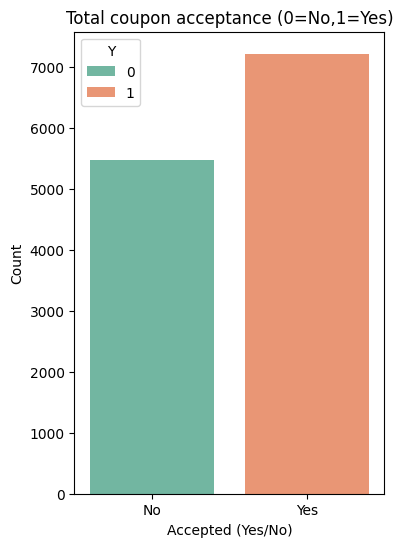

In [41]:
#Calculate the total percentage of coupons were accepted

total_acceptance = data['Y'].mean()
print ("Overall acceptance rate = ",total_acceptance)

#visualize the total percentage
plt.figure(figsize=(4,6))
sns.countplot(data=data,palette='Set2',x='Y',hue='Y')
plt.title("Total coupon acceptance (0=No,1=Yes)")
plt.xlabel("Accepted (Yes/No)")
plt.ylabel("Count")
plt.xticks([0,1],['No','Yes'])
plt.show()

#### 5. Use a bar plot to visualize the `coupon` column.

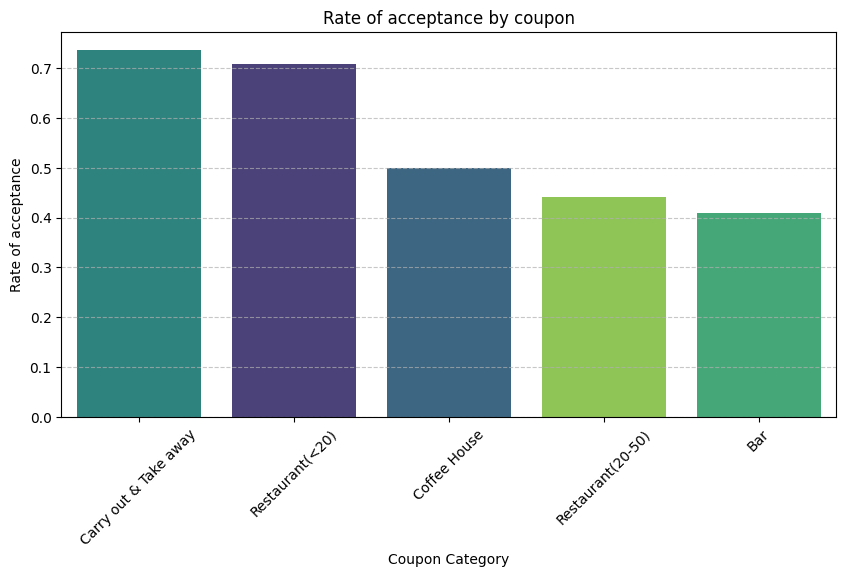

In [39]:
#Determine the most popular coupon
plt.figure(figsize=(10,5))
sns.barplot(x='coupon',y='Y',data=data,errorbar=None,palette='viridis',order=data.groupby('coupon')['Y'].mean().sort_values(ascending=False).index,hue='coupon')
plt.title('Rate of acceptance by coupon')
plt.xlabel('Coupon Category')
plt.ylabel('Rate of acceptance')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

#### 5.1 Observation
##### Carry out and Take away coupons have the highest acceptance ratio followed by affordable restaurant. Bars are the least accepted coupon category.

#### 6. Use a histogram to visualize the temperature column.

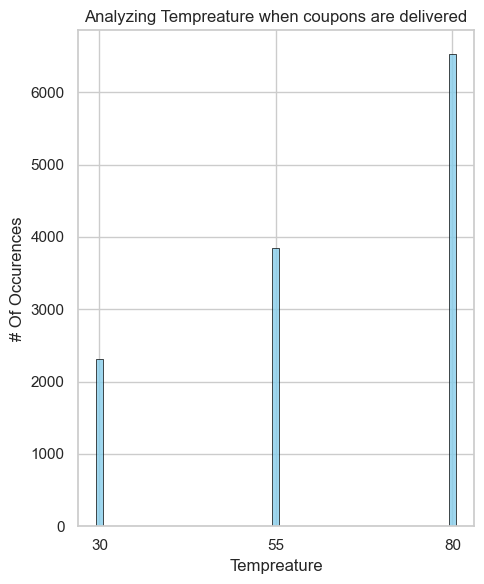

In [62]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5,6))
sns.histplot(data=data,x="temperature",discrete=True,color='skyblue',edgecolor='black',alpha=0.8)
plt.title('Analyzing Tempreature when coupons are delivered')
plt.xlabel('Tempreature')
plt.ylabel('# Of Occurences')
plt.xticks([30,55,80])
plt.tight_layout()
plt.show()

#### 6.1 Observation
##### Above plot shows the number of coupons delivered were more than doubled at 80 degree farenhiet than 30 and 55.

Lets now see how the tempreature impacts the coupon acceptance

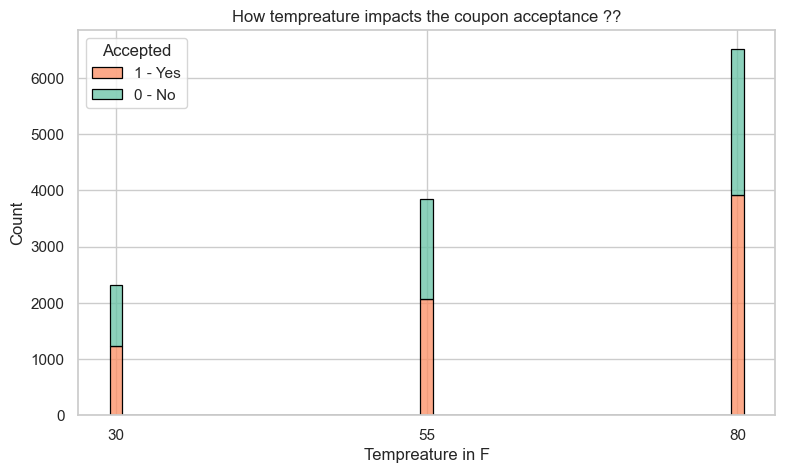

In [71]:
plt.figure(figsize=(9,5))
sns.histplot(data=data,x='temperature',hue='Y',discrete=True,multiple='stack',palette='Set2',edgecolor='black')
plt.title("How tempreature impacts the coupon acceptance ??")
plt.xlabel('Tempreature in F')
plt.ylabel('Count')
plt.xticks([30,55,80])
plt.legend(title="Accepted",labels=['1 - Yes','0 - No'])

#### 6.2 Observation
##### In all the tempreatures more or less the acceptance ratio was around 50% which is closer to the overall acceptance ratio.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

##### 1. Create a new `DataFrame` that contains just the bar coupons.


In [131]:
bar_data=data.query("coupon == 'Bar'")
print(bar_data.info())
bar_data.head()

<class 'pandas.DataFrame'>
Index: 2017 entries, 9 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           2017 non-null   str  
 1   passanger             2017 non-null   str  
 2   weather               2017 non-null   str  
 3   temperature           2017 non-null   int64
 4   time                  2017 non-null   str  
 5   coupon                2017 non-null   str  
 6   expiration            2017 non-null   str  
 7   gender                2017 non-null   str  
 8   age                   2017 non-null   str  
 9   maritalStatus         2017 non-null   str  
 10  has_children          2017 non-null   int64
 11  education             2017 non-null   str  
 12  occupation            2017 non-null   str  
 13  income                2017 non-null   str  
 14  Bar                   2017 non-null   str  
 15  CoffeeHouse           2017 non-null   str  
 16  CarryAway            

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


##### 2. What proportion of bar coupons were accepted?


In [76]:
bar_coupon_accepted = bar_data['Y'].mean()
bar_coupon_accepted

np.float64(0.41001487357461575)

##### 3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [82]:
#Create a new column and evaluate the values of 'Bar'. Populate the new column with frequent or infrequent visitor
def freq_bar_goer(val):
    if val in ['never','less1','1~3']:
        return 'Infrequent (<=3 / month)'
    else:
        return 'frequent (>3 / month)'
bar_data['bar_frequency'] = bar_data['Bar'].apply(freq_bar_goer)

Bar
never    851
less1    570
1~3      397
4~8      150
gt8       49
Name: count, dtype: int64
bar_frequency
Infrequent (<=3 / month)    1818
frequent (>3 / month)        199
Name: count, dtype: int64


Text(0, 0.5, 'Acceptance Ratio')

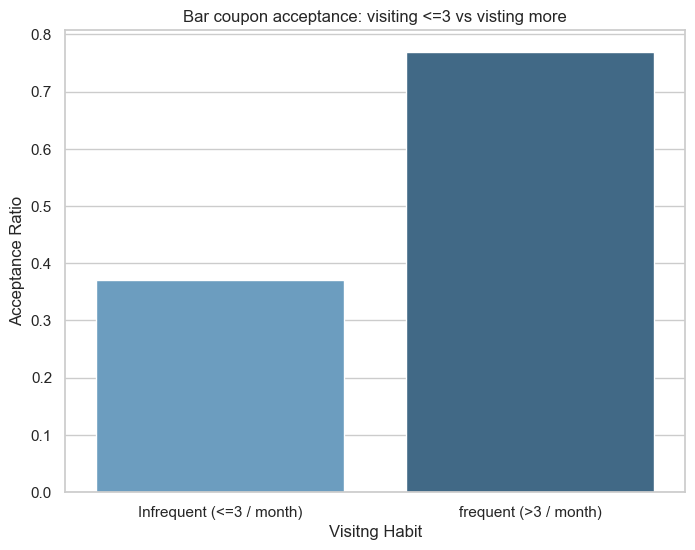

In [94]:
#plot to compare the acceptance
plt.figure(figsize=(8,6))
sns.barplot(x='bar_frequency',y='Y',data=bar_data,errorbar=None,palette='Blues_d',hue='bar_frequency')
plt.title("Bar coupon acceptance: visiting <=3 vs visting more")
plt.xlabel('Visitng Habit')
plt.ylabel('Acceptance Ratio')
plt.show()

#### 3.1 Observation
##### Acceptance ratio for frequent bar goers is more than 70% where as in frequent bar goers coupon acceptance ratio is less than 40%

##### 4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


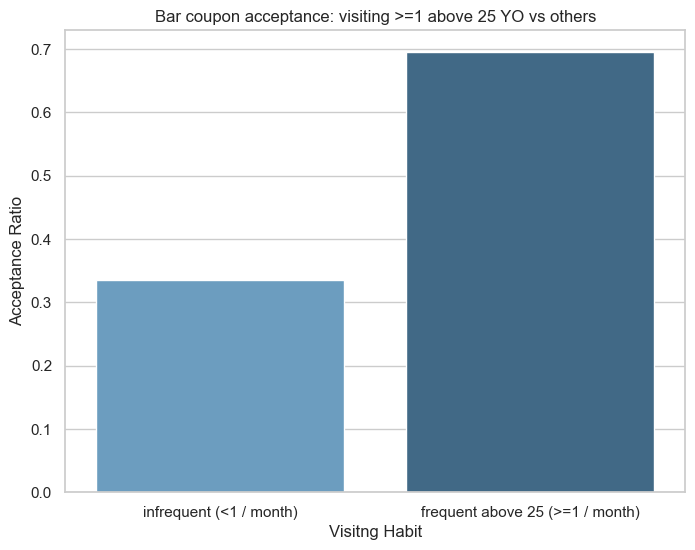

In [106]:
def freq_bar_goer_age(freq,age):
    if freq in ['1~3','4~8','gt8'] and age not in ['21','below21',]:
        return 'frequent above 25 (>=1 / month)'
    else:
        return 'infrequent (<1 / month)'

#create a new colum to categorize the frequency of vists. 
#Use lambda fucntion to pass 2 arguments to the function.
bar_data['bar_frequency_age_above_25'] = bar_data.apply(lambda row: freq_bar_goer_age(row['Bar'],row['age']),axis=1)
plt.figure(figsize=(8,6))
sns.barplot(x='bar_frequency_age_above_25',y='Y',data=bar_data,errorbar=None,palette='Blues_d',hue='bar_frequency_age_above_25')
plt.title("Bar coupon acceptance: visiting >=1 above 25 YO vs others")
plt.xlabel('Visitng Habit')
plt.ylabel('Acceptance Ratio')
plt.show()

#### 4.1 Observation
##### Frequest bar goers above 25 years old acceptance ration is almost 70% where as infrequent bar goers accept only little above 30%.

##### 5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


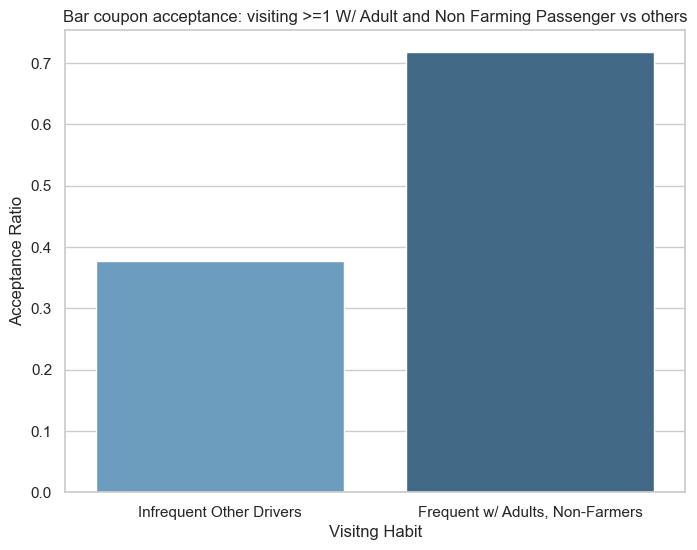

In [109]:
def freq_bar_goer_driver_with_pass(freq,passengers,occupation):
    if freq in ['1~3','4~8','gt8'] and passengers in ['Friend(s)', 'Partner'] and occupation not in ['Farming Fishing & Forestry']:
        return 'Frequent w/ Adults, Non-Farmers'
    else:
        return 'Infrequent Other Drivers'

#create a new colum to categorize the frequency of vists. 
#Use lambda fucntion to pass 2 arguments to the function.
bar_data['bar_freq_drivers_with_pass'] = bar_data.apply(lambda row: freq_bar_goer_driver_with_pass(row['Bar'],row['passanger'],row['occupation']),axis=1)
# print(bar_data['occupation'].value_counts())
plt.figure(figsize=(8,6))
sns.barplot(x='bar_freq_drivers_with_pass',y='Y',data=bar_data,errorbar=None,palette='Blues_d',hue='bar_freq_drivers_with_pass')
plt.title("Bar coupon acceptance: visiting >=1 W/ Adult and Non Farming Passenger vs others")
plt.xlabel('Visitng Habit')
plt.ylabel('Acceptance Ratio')
plt.show()

##### 6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



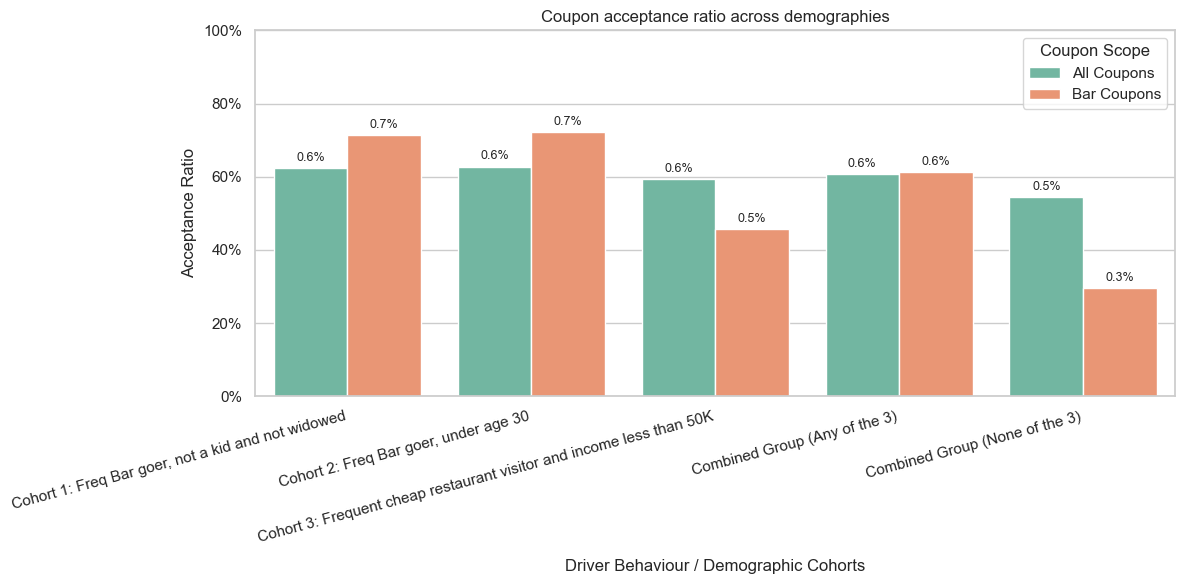

In [155]:
bar_visit_ge1_filter = ['1~3','4~8','gt8']
under_age_30_filter = ['21','26','below21']
cheap_restaurant_visit_ge4_filter = ['4~8','gt8']
income_lt50_filter = ['$25000 - $37499','$12500 - $24999','$37500 - $49999']
cond1 = (bar_data['Bar'].isin(bar_visit_ge1_filter)) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['maritalStatus'] != 'Widowed')
cond2 = (bar_data['Bar'].isin(bar_visit_ge1_filter)) & (bar_data['age'].isin(under_age_30_filter))
cond3 = (bar_data['RestaurantLessThan20'].isin(cheap_restaurant_visit_ge4_filter)) & (bar_data['income'].isin(income_lt50_filter))


#Create data summary with different category
data_summary = []

for category,data_slice in [('All Coupons',data),('Bar Coupons',bar_data)]:
    s_cond1 = (data_slice['Bar'].isin(bar_visit_ge1_filter)) & (data_slice['passanger'] != 'Kid(s)') & (data_slice['maritalStatus'] != 'Widowed')
    s_cond2 = (data_slice['Bar'].isin(bar_visit_ge1_filter)) & (data_slice['age'].isin(under_age_30_filter))
    s_cond3 = (data_slice['RestaurantLessThan20'].isin(cheap_restaurant_visit_ge4_filter)) & (data_slice['income'].isin(income_lt50_filter))
    s_any = s_cond1 | s_cond2 | s_cond3

    data_summary.append({'Category': category,'Cohort':'Cohort 1: Freq Bar goer, not a kid and not widowed','Acceptance Ratio':data_slice[s_cond1]['Y'].mean()})
    data_summary.append({'Category': category,'Cohort':'Cohort 2: Freq Bar goer, under age 30','Acceptance Ratio':data_slice[s_cond2]['Y'].mean()})
    data_summary.append({'Category': category,'Cohort':'Cohort 3: Frequent cheap restaurant visitor and income less than 50K','Acceptance Ratio':data_slice[s_cond3]['Y'].mean()})
    data_summary.append({'Category': category,'Cohort':'Combined Group (Any of the 3)','Acceptance Ratio':data_slice[s_any]['Y'].mean()})
    data_summary.append({'Category': category,'Cohort':'Combined Group (None of the 3)','Acceptance Ratio':data_slice[~s_any]['Y'].mean()})

plot_df = pd.DataFrame(data_summary)

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

ax=sns.barplot(data=plot_df,x='Cohort',y='Acceptance Ratio',hue='Category',palette='Set2')

plt.title('Coupon acceptance ratio across demographies')
plt.xlabel('Driver Behaviour / Demographic Cohorts',fontsize=12,labelpad=10)
plt.ylabel('Acceptance Ratio')
plt.ylim(0,1.0)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks(rotation=15,ha='right')

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',padding=3,fontsize=9)

plt.legend(title='Coupon Scope',frameon=True)
plt.tight_layout()
plt.show()

##### 7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Drivers go to bars more than once a month, had passengers that were not a kid, and were not widowed accept bar coupons more than any other coupons.

Drivers go to bars more than once a month and are under the age of 30 accept bar coupons more than all other coupons.

Drivers go to cheap restaurants more than 4 times a month and income is less than 50K accept other coupons more than bar coupons.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

##### Coffee house coupon analysis
Let's apply a similar demographic and environmental lens to Coffee House coupons.

In [146]:
coffee_data = data.query(("coupon == 'Coffee House'"))
coffee_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


checking if weather conditions or time of day sway drivers.

C:\Users\sbrit\AppData\Local\Temp\ipykernel_25448\1871269719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather',y='Y',data=coffee_data,errorbar=None,ax=axes[0],palette='Set1')
C:\Users\sbrit\AppData\Local\Temp\ipykernel_25448\1871269719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time',y='Y',data=coffee_data,errorbar=None,ax=axes[1],palette='rocket',order=['7AM', '10AM', '2PM', '6PM', '10PM'])


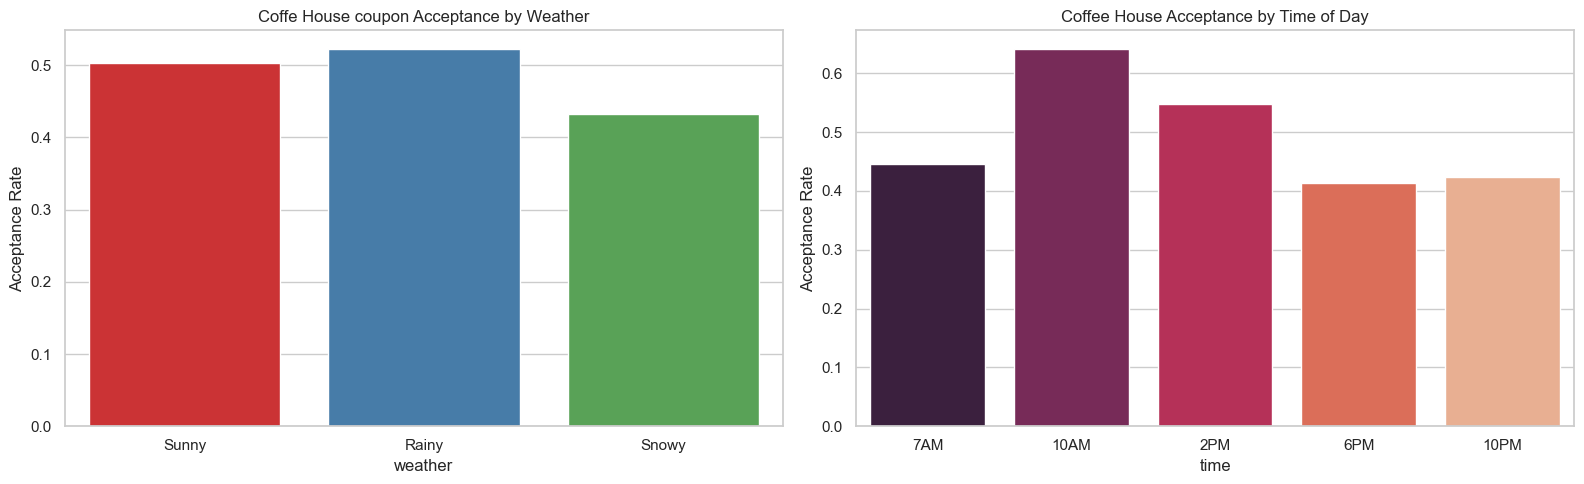

In [150]:
fig,axes = plt.subplots(1,2,figsize=(16,5))

sns.barplot(x='weather',y='Y',data=coffee_data,errorbar=None,ax=axes[0],palette='Set1')
axes[0].set_title('Coffe House coupon Acceptance by Weather')
axes[0].set_ylabel('Acceptance Rate')

sns.barplot(x='time',y='Y',data=coffee_data,errorbar=None,ax=axes[1],palette='rocket',order=['7AM', '10AM', '2PM', '6PM', '10PM'])
axes[1].set_title('Coffee House Acceptance by Time of Day')
axes[1].set_ylabel('Acceptance Rate')

plt.tight_layout()
plt.show()

#### Observation

##### Coffee coupon acceptance is more during rainy weather followed by sunny

##### Coffee coupon acceptance is more at 10 AM followed by 2 PM

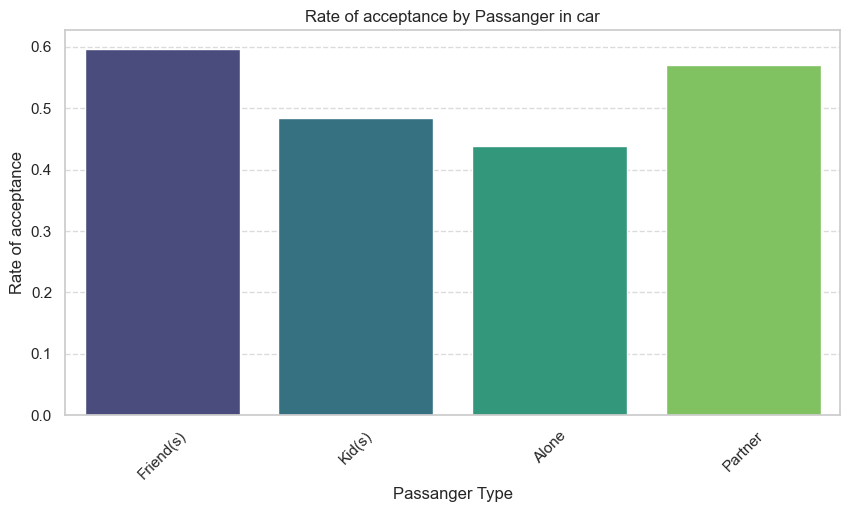

In [160]:
plt.figure(figsize=(10,5))
sns.barplot(x='passanger',y='Y',data=coffee_data,errorbar=None,palette='viridis',hue='passanger')
plt.title('Rate of acceptance by Passanger in car')
plt.xlabel('Passanger Type')
plt.ylabel('Rate of acceptance')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

In [161]:
coffee_data['CoffeeHouse'].value_counts()

CoffeeHouse
less1    1147
1~3      1042
never     927
4~8       538
gt8       342
Name: count, dtype: int64

coupon
Coffee House    1922
Name: count, dtype: int64


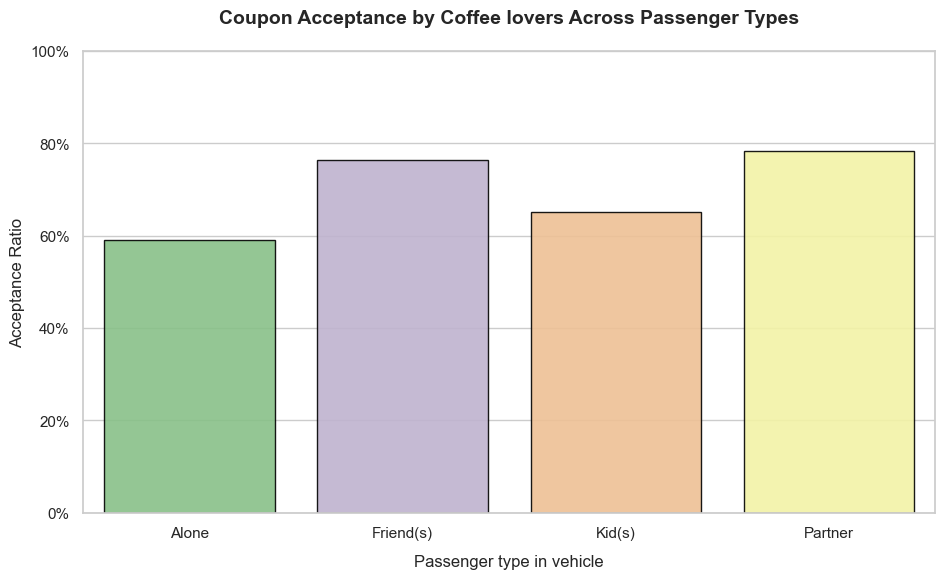

In [179]:
#Filter drivers visit coffee shop at least 1 time a month
freq_coffee_visit = ['1~3','4~8','gt8']
coffee_data_frequent = coffee_data[coffee_data['CoffeeHouse'].isin(freq_coffee_visit)].copy()


#Filter drivers who got coffee house coupon 
coffee_data_coffee_coupon = coffee_data_frequent[coffee_data_frequent['coupon']=='Coffee House'].copy()
coffee_accept_rate = coffee_data_coffee_coupon.groupby('passanger')['Y'].mean().reset_index()
coffee_accept_rate['Coupon Type'] = 'Coffee House Coupons Only'

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))

ax=sns.barplot(data=coffee_accept_rate,x='passanger',y='Y',hue='passanger',palette='Accent',edgecolor='black',alpha=0.9)

plt.title('Coupon Acceptance by Coffee lovers Across Passenger Types',fontsize=14,fontweight='bold',pad=20)
plt.xlabel('Passenger type in vehicle',fontsize=12,labelpad=10)
plt.ylabel('Acceptance Ratio',fontsize=12)
plt.ylim(0,1.0)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


#### Observation
##### It is very interesting that the frequent cofee goers while driving alone the acceptance ratio is very less.

##### Drivers travelling with partner or friends who goes to coffee shop frequentlly accept almost 80% of the times.

##### Drivers travelling with kids also not accepting the coupons much. 
